# Training plots

## Architectural tuning

Generating Neural Network Plots...


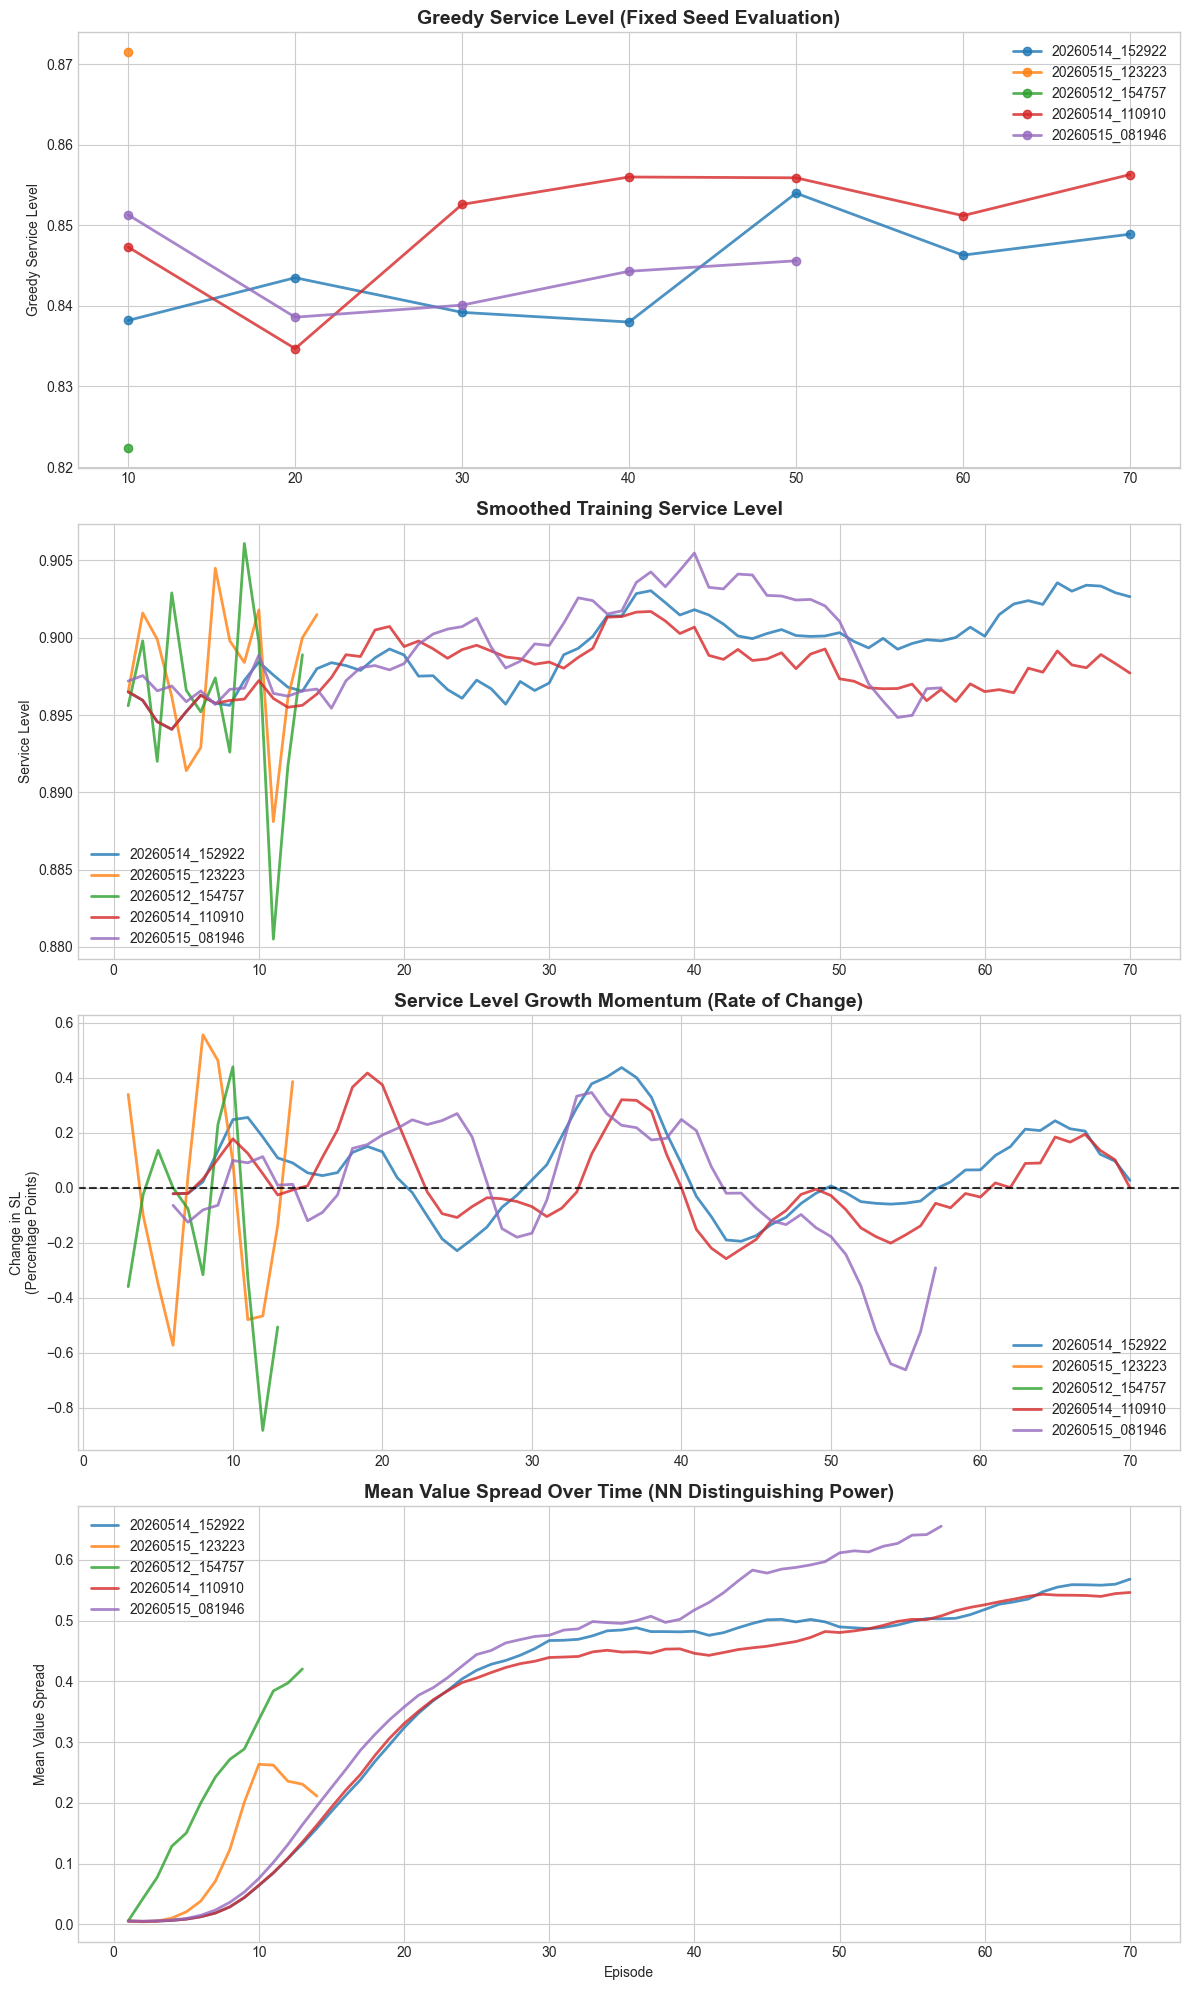


Generating Linear VFA Plots...
VFA log file 'vfa_Squared_Temporal_seed1000_weights_evolution.csv' not found.


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Set global plot style for better looking graphs
plt.style.use('seaborn-v0_8-whitegrid')

# =====================================================================
# 1. NEURAL NETWORK ARCHITECTURE COMPARISON
# =====================================================================
print("Generating Neural Network Plots...")
# Support checking in models folder or current directory
nn_files = glob.glob("policies/sjovik_sund/NN/models/training_log_seed1000_*.csv")
if not nn_files:
    nn_files = glob.glob("training_log_seed1000_*.csv")

valid_dfs = []

# Safely load files and skip empty ones
for f in nn_files:
    try:
        df = pd.read_csv(f)
        if not df.empty:
            # Extract the timestamp from the filename instead of the architecture
            # Example filename: training_log_seed1000_arch_128-64-32_20260429_125756.csv
            basename = os.path.basename(f).replace('.csv', '')
            
            # The timestamp is usually the last two parts separated by an underscore
            parts = basename.split('_')
            if len(parts) >= 2:
                run_label = f"{parts[-2]}_{parts[-1]}"  # e.g., "20260429_125756"
            else:
                run_label = basename
                
            valid_dfs.append((run_label, df))
    except pd.errors.EmptyDataError:
        print(f"  [Warning] Skipping empty file: {f}")
    except Exception as e:
        print(f"  [Warning] Could not read {f}: {e}")

if valid_dfs:
    # 4 subplots to include the Growth Momentum
    fig, (ax1, ax2, ax_growth, ax3) = plt.subplots(4, 1, figsize=(12, 20))
    
    for run_label, df in valid_dfs:
        # 1. Plot Greedy SL (Evaluated periodically)
        if 'greedy_sl' in df.columns:
            df_greedy = df[df['greedy_sl'].notna()]
            if not df_greedy.empty:
                ax1.plot(df_greedy['episode'], df_greedy['greedy_sl'], 
                         marker='o', label=run_label, linewidth=2, alpha=0.8)
            
        # 2. Plot Smoothed Training SL
        if 'service_level' in df.columns:
            window = min(20, max(1, len(df)//10))
            df['service_level_smooth'] = df['service_level'].rolling(window=window, min_periods=1).mean()
            ax2.plot(df['episode'], df['service_level_smooth'], label=run_label, linewidth=2, alpha=0.8)
            
            # 3. Plot Growth Momentum
            growth_window = min(5, max(1, len(df)//5))
            df['sl_growth'] = df['service_level_smooth'].diff(periods=growth_window) * 100 
            df['sl_growth_smooth'] = df['sl_growth'].rolling(window=3, min_periods=1).mean()
            ax_growth.plot(df['episode'], df['sl_growth_smooth'], label=run_label, linewidth=2, alpha=0.8)

        # 4. Plot Smoothed Value Spread
        if 'mean_value_spread' in df.columns:
            df['spread_smooth'] = df['mean_value_spread'].rolling(window=window, min_periods=1).mean()
            ax3.plot(df['episode'], df['spread_smooth'], label=run_label, linewidth=2, alpha=0.8)

    # Formatting NN plots
    ax1.set_title('Greedy Service Level (Fixed Seed Evaluation)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Greedy Service Level')
    ax1.legend()

    ax2.set_title('Smoothed Training Service Level', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Service Level')
    ax2.legend()

    # Formatting Growth plot
    ax_growth.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.8) # Baseline zero
    ax_growth.set_title('Service Level Growth Momentum (Rate of Change)', fontsize=14, fontweight='bold')
    ax_growth.set_ylabel('Change in SL\n(Percentage Points)')
    ax_growth.legend()

    ax3.set_title('Mean Value Spread Over Time (NN Distinguishing Power)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Mean Value Spread')
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No valid Neural Network logs found.")


# =====================================================================
# 2. LINEAR VFA CONVERGENCE (REWARD SHAPING)
# =====================================================================
print("\nGenerating Linear VFA Plots...")
vfa_file = 'vfa_Squared_Temporal_seed1000_weights_evolution.csv'

if os.path.exists(vfa_file):
    try:
        df_vfa = pd.read_csv(vfa_file)
        
        # Dynamically find the weight columns (ignoring state/metrics columns)
        exclude_cols = ['episode', 'service_level', 'starvations', 'long_congestions', 'short_congestions']
        weight_cols = [col for col in df_vfa.columns if col not in exclude_cols]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        # 1. Plot VFA Service Level
        window_size = min(20, max(1, len(df_vfa) // 10))
        df_vfa['service_level_smooth'] = df_vfa['service_level'].rolling(window=window_size, min_periods=1).mean()
        
        ax1.plot(df_vfa['episode'], df_vfa['service_level'], color='lightgrey', alpha=0.5, label='Raw Service Level')
        ax1.plot(df_vfa['episode'], df_vfa['service_level_smooth'], color='blue', linewidth=2, label=f'Smooth SL (win={window_size})')
        
        ax1.set_ylabel('Service Level', fontsize=12)
        ax1.set_title(f'VFA Service Level Evolution (up to episode {len(df_vfa)-1})', fontsize=14, fontweight='bold')
        ax1.legend()

        # 2. Plot VFA Weights
        for col in weight_cols:
            # Formats the column name nicely for the legend
            nice_label = col.replace('_', ' ').title()
            ax2.plot(df_vfa['episode'], df_vfa[col], label=nice_label, linewidth=2)
            
        ax2.set_xlabel('Episode', fontsize=12)
        ax2.set_ylabel('Weight Value', fontsize=12)
        ax2.set_title('VFA Weights Evolution', fontsize=14, fontweight='bold')
        ax2.legend()

        plt.tight_layout()
        plt.show()
    except pd.errors.EmptyDataError:
        print(f"  [Warning] VFA file '{vfa_file}' is empty and was skipped.")
else:
    print(f"VFA log file '{vfa_file}' not found.")